In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data = data.dropna(subset=["TotalCharges"]).copy()

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

display(data.head())

Dataset loaded successfully!
Dataset shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
monthly_customers = (
    data.groupby("tenure")
    .size()
    .reset_index(name="CustomerCount")
)

monthly_customers = monthly_customers.sort_values("tenure")

display(monthly_customers.head(10))

,tenure,CustomerCount
0,1,613
1,2,238
2,3,200
3,4,176
4,5,133
5,6,110
6,7,131
7,8,123
8,9,119
9,10,116


In [4]:
monthly_customers["Date"] = pd.date_range(
    start="2020-01-01",
    periods=len(monthly_customers),
    freq="MS"
)

monthly_customers = monthly_customers[
    ["Date", "CustomerCount"]
]

display(monthly_customers.head())

,Date,CustomerCount
0,2020-01-01,613
1,2020-02-01,238
2,2020-03-01,200
3,2020-04-01,176
4,2020-05-01,133


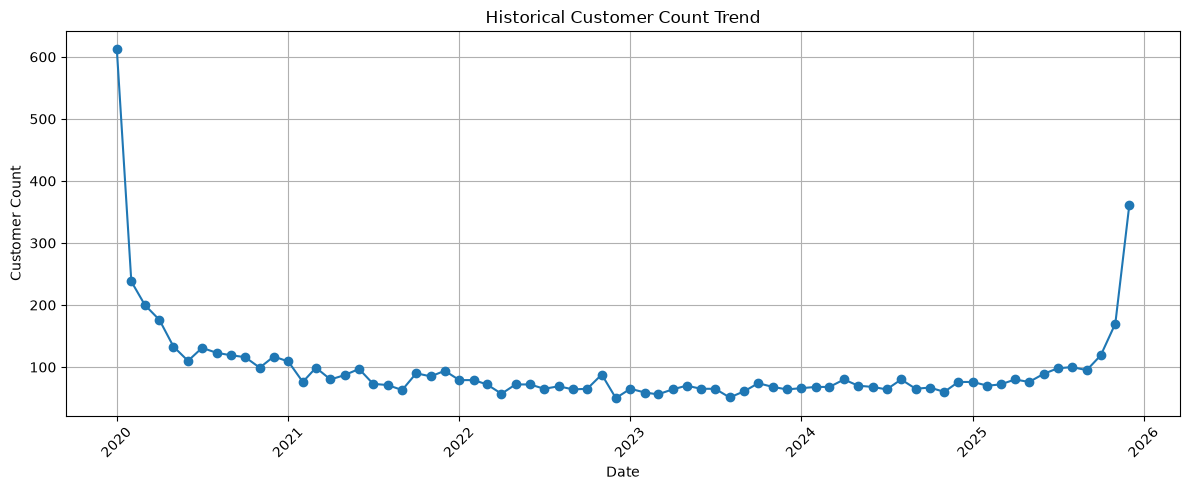

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_customers["Date"],
    monthly_customers["CustomerCount"],
    marker="o"
)

plt.title("Historical Customer Count Trend")
plt.xlabel("Date")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "day36_customer_growth_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
growth_change = (
    monthly_customers["CustomerCount"].iloc[-1]
    - monthly_customers["CustomerCount"].iloc[0]
)

print("Customer count change:", growth_change)

if growth_change > 0:
    print("Overall pattern: Growth")
elif growth_change < 0:
    print("Overall pattern: Decline")
else:
    print("Overall pattern: Stable")

Customer count change: -251
Overall pattern: Decline


In [7]:
monthly_customers["RollingAverage"] = (
    monthly_customers["CustomerCount"]
    .rolling(window=3)
    .mean()
)

display(monthly_customers.head(10))

,Date,CustomerCount,RollingAverage
0,2020-01-01,613,NaN
1,2020-02-01,238,NaN
2,2020-03-01,200,350.333333
3,2020-04-01,176,204.666667
4,2020-05-01,133,169.666667
5,2020-06-01,110,139.666667
6,2020-07-01,131,124.666667
7,2020-08-01,123,121.333333
8,2020-09-01,119,124.333333
9,2020-10-01,116,119.333333


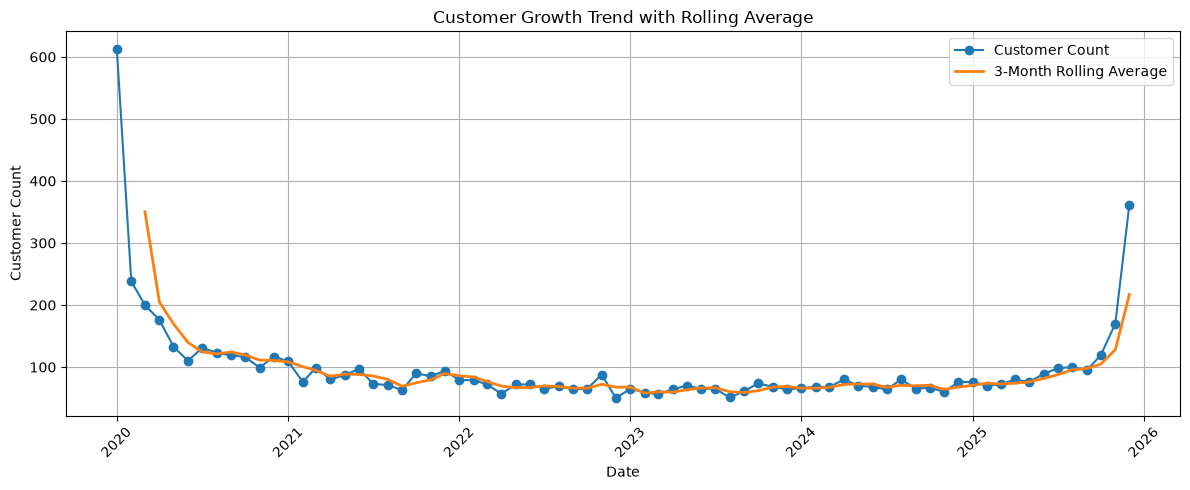

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_customers["Date"],
    monthly_customers["CustomerCount"],
    marker="o",
    label="Customer Count"
)

plt.plot(
    monthly_customers["Date"],
    monthly_customers["RollingAverage"],
    linewidth=2,
    label="3-Month Rolling Average"
)

plt.title("Customer Growth Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "day36_customer_growth_rolling_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
forecast_data = monthly_customers[
    ["Date", "CustomerCount"]
].copy()

forecast_data = forecast_data.set_index("Date")

print("Forecasting data prepared!")
display(forecast_data.head())

Forecasting data prepared!


,CustomerCount
Date,
2020-01-01,613
2020-02-01,238
2020-03-01,200
2020-04-01,176
2020-05-01,133


In [10]:
window = 3

baseline_value = (
    forecast_data["CustomerCount"]
    .tail(window)
    .mean()
)

print("Baseline forecast value:", round(baseline_value, 2))

Baseline forecast value: 217.0


In [11]:
future_dates = pd.date_range(
    start=forecast_data.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

forecast = pd.DataFrame({
    "Date": future_dates,
    "PredictedCustomerCount": baseline_value
})

display(forecast.head(10))
print("Number of forecast days:", len(forecast))

,Date,PredictedCustomerCount
0,2025-12-02,217.0
1,2025-12-03,217.0
2,2025-12-04,217.0
3,2025-12-05,217.0
4,2025-12-06,217.0
5,2025-12-07,217.0
6,2025-12-08,217.0
7,2025-12-09,217.0
8,2025-12-10,217.0
9,2025-12-11,217.0


Number of forecast days: 30


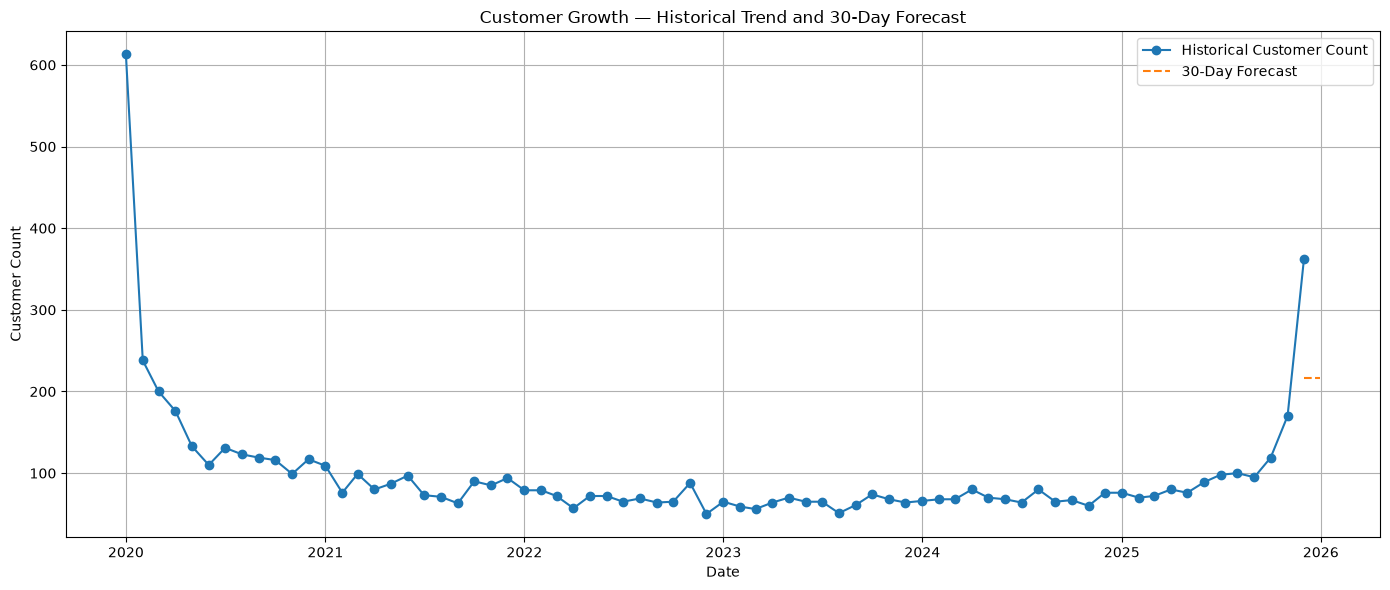

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    forecast_data.index,
    forecast_data["CustomerCount"],
    marker="o",
    label="Historical Customer Count"
)

plt.plot(
    forecast["Date"],
    forecast["PredictedCustomerCount"],
    linestyle="--",
    label="30-Day Forecast"
)

plt.title("Customer Growth — Historical Trend and 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Customer Count")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "day36_30_day_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
forecast.to_csv(
    "day36_30_day_customer_forecast.csv",
    index=False
)

print("30-day forecast saved successfully!")
display(forecast.head(10))

30-day forecast saved successfully!


,Date,PredictedCustomerCount
0,2025-12-02,217.0
1,2025-12-03,217.0
2,2025-12-04,217.0
3,2025-12-05,217.0
4,2025-12-06,217.0
5,2025-12-07,217.0
6,2025-12-08,217.0
7,2025-12-09,217.0
8,2025-12-10,217.0
9,2025-12-11,217.0


In [14]:
observations = f"""
DAY 36 — FORECASTING OBSERVATIONS AND RISKS

Forecasting Method:
Moving-average baseline using the most recent {window} observations.

Forecast Horizon:
30 days.

Baseline Forecast:
{baseline_value:.2f} customers per forecast period.

Observations:
- The historical customer series shows variation across tenure periods.
- The rolling average helps smooth short-term fluctuations.
- The baseline model provides a simple reference forecast.
- The 30-day predictions remain constant because a moving-average
  baseline does not model changing trends or seasonality.

Risks and Limitations:
- The Telco dataset does not contain actual historical dates.
- Dates used in this exercise are an artificial time index.
- Therefore, the forecast should be treated as a learning demonstration,
  not as a real business prediction.
- The baseline model does not explicitly capture seasonality,
  holidays, campaigns, or external business factors.
- Real forecasting should use genuine dated historical observations
  and a model validated on time-based data.
"""

print(observations)

with open(
    "day36_forecasting_observations_and_risks.txt",
    "w"
) as file:
    file.write(observations)


DAY 36 — FORECASTING OBSERVATIONS AND RISKS

Forecasting Method:
Moving-average baseline using the most recent 3 observations.

Forecast Horizon:
30 days.

Baseline Forecast:
217.00 customers per forecast period.

Observations:
- The historical customer series shows variation across tenure periods.
- The rolling average helps smooth short-term fluctuations.
- The baseline model provides a simple reference forecast.
- The 30-day predictions remain constant because a moving-average
  baseline does not model changing trends or seasonality.

Risks and Limitations:
- The Telco dataset does not contain actual historical dates.
- Dates used in this exercise are an artificial time index.
- Therefore, the forecast should be treated as a learning demonstration,
  not as a real business prediction.
- The baseline model does not explicitly capture seasonality,
  holidays, campaigns, or external business factors.
- Real forecasting should use genuine dated historical observations
  and a model val